The even and odd FBP tomograms are kept fixed for all conditions and originate from the same acquisition geometry. The model checkpoint is also fixed and was trained with mw_angle = 50°. For the inference-time angle sweep, I only vary the mw_angle parameter used during refinement, which changes the Fourier mask defining which region is treated as missing and filled by the model prediction. For each assumed angle, the even and odd tomograms are refined separately and their FSC is computed to estimate the reproducible resolution.

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from ddw.utils.mrctools import load_mrc_data

C:\Users\chris\anaconda3\envs\ddw_env\lib\site-packages\lightning_utilities\core\imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def load_volume(path):
    vol = load_mrc_data(path)
    if isinstance(vol, torch.Tensor):
        vol = vol.cpu().numpy()
    return vol.astype(np.float32)

In [3]:
from pathlib import Path

angles = [30, 40, 50, 60, 70]


data_dir = Path("../../experiments/subexp01")
output_dir = Path("../../results")

refined_pairs = {
    angle: (
        data_dir / f"run_mw{angle}/tomo_even_frames_mw{angle}_refined.rec",
        data_dir / f"run_mw{angle}/tomo_odd_frames_mw{angle}_refined.rec",
    )
    for angle in angles
}


even_refined_by_angle = {}
odd_refined_by_angle = {}

for angle, (even_path, odd_path) in refined_pairs.items():
    even_refined_by_angle[angle] = load_volume(even_path)
    odd_refined_by_angle[angle] = load_volume(odd_path)

In [4]:
#Fourier Shell Correlation
def compute_fsc(vol1, vol2, num_shells=None):
    """
    Compute Fourier Shell Correlation between two 3D volumes.

    Parameters
    ----------
    vol1, vol2 : np.ndarray
        3D volumes with the same shape, usually ordered as (z, y, x).
    num_shells : int or None
        Number of radial Fourier shells. If None, use half the smallest dimension.

    Returns
    -------
    shell_frequencies : np.ndarray
        Normalized shell frequencies from low to high frequency.
    fsc_values : np.ndarray
        FSC values for each shell.
    """
    assert vol1.shape == vol2.shape, "Volumes must have the same shape."

    # Fourier transform and shift zero frequency to center
    F1 = np.fft.fftshift(np.fft.fftn(vol1))
    F2 = np.fft.fftshift(np.fft.fftn(vol2))

    shape = vol1.shape

    if num_shells is None:
        num_shells = min(shape) // 2

    # Create coordinate grid in Fourier space
    z, y, x = np.indices(shape)
    center = np.array(shape) // 2

    # Radial distance from Fourier center
    r = np.sqrt(
        (z - center[0])**2 +
        (y - center[1])**2 +
        (x - center[2])**2
    )

    r_max = min(shape) // 2
    shell_edges = np.linspace(0, r_max, num_shells + 1)

    shell_frequencies = []
    fsc_values = []

    for i in range(num_shells):
        shell_mask = (r >= shell_edges[i]) & (r < shell_edges[i + 1])

        if np.sum(shell_mask) == 0:
            shell_frequencies.append(np.nan)
            fsc_values.append(np.nan)
            continue

        F1_shell = F1[shell_mask]
        F2_shell = F2[shell_mask]

        numerator = np.sum(F1_shell * np.conj(F2_shell))
        denominator = np.sqrt(
            np.sum(np.abs(F1_shell)**2) *
            np.sum(np.abs(F2_shell)**2)
        )

        if denominator == 0:
            fsc = np.nan
        else:
            fsc = np.real(numerator / denominator)

        shell_center = 0.5 * (shell_edges[i] + shell_edges[i + 1])
        normalized_frequency = shell_center / r_max

        shell_frequencies.append(normalized_frequency)
        fsc_values.append(fsc)

    return np.array(shell_frequencies), np.array(fsc_values)

In [5]:
def get_fsc_threshold_frequency(freqs, fsc_values, threshold=0.5):
    """
    Return the first frequency where FSC drops below the given threshold.
    Uses simple linear interpolation between neighbouring points.
    """
    valid = np.isfinite(freqs) & np.isfinite(fsc_values)
    freqs = freqs[valid]
    fsc_values = fsc_values[valid]

    for i in range(1, len(fsc_values)):
        if fsc_values[i - 1] >= threshold and fsc_values[i] < threshold:
            x0, x1 = freqs[i - 1], freqs[i]
            y0, y1 = fsc_values[i - 1], fsc_values[i]

            if y1 == y0:
                return x1

            # linear interpolation
            return x0 + (threshold - y0) * (x1 - x0) / (y1 - y0)

    return np.nan

In [6]:
def mean_fsc_in_band(freqs, fsc, fmin=0.7, fmax=1.0):
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.nanmean(fsc[mask])

In [7]:
fsc_results = {}
summary_rows = []
voxel_size_A = 14.13

for angle in angles:
    even_vol = even_refined_by_angle[angle]
    odd_vol = odd_refined_by_angle[angle]

    freqs, fsc_values = compute_fsc(even_vol, odd_vol)
    fsc_05_freq = get_fsc_threshold_frequency(freqs, fsc_values, threshold=0.5)
    fsc_mean_high_freq = mean_fsc_in_band(freqs, fsc_values)

    if np.isfinite(fsc_05_freq):
        resolution_voxels = 2 / fsc_05_freq
        resolution_A = 2 * voxel_size_A / fsc_05_freq
    else:
        resolution_voxels = np.nan
        resolution_A = np.nan

    fsc_results[angle] = {
        "freqs": freqs,
        "fsc": fsc_values,
        "fsc_05_freq": fsc_05_freq,
        "resolution_voxels": resolution_voxels,
        "resolution_A": resolution_A,
    }

    summary_rows.append({
        "mw_angle": angle,
        "fsc_0.5_frequency_normalized": fsc_05_freq,
        "resolution_voxels": resolution_voxels,
        "resolution_A": resolution_A,
        "fsc_mean_high_freq": fsc_mean_high_freq,
    })

summary = pd.DataFrame(summary_rows)
summary

#Save
summary_path = Path("../../results/subexp01/FSC_even_odd_Resolution_Summary.csv")
summary.to_csv(summary_path, index=False)

print("Saved summary to:", os.path.abspath(summary_path))
summary

Saved summary to: C:\Users\chris\Desktop\Fabio\semester-project-deepdewedge\results\subexp01\FSC_even_odd_Resolution_Summary.csv


,mw_angle,fsc_0.5_frequency_normalized,resolution_voxels,resolution_A,fsc_mean_high_freq
0,30,NaN,NaN,NaN,0.769945
1,40,NaN,NaN,NaN,0.784372
2,50,NaN,NaN,NaN,0.793731
3,60,NaN,NaN,NaN,0.810779
4,70,NaN,NaN,NaN,0.818906


In [8]:
#empty list
curve_rows = []

# key and value, take out one result from the dict (fsc_result)
for angle, result in fsc_results.items():
    
    # Extract the x-values and y-values of the FSC curve
    freqs = result["freqs"]
    fsc_values = result["fsc"]

    # loop over all data points, store them row for row, datapoints are below each other
    for freq, fsc in zip(freqs, fsc_values):
        
        #storing each row
        curve_rows.append({
            "experiment": "subexp01_inference_angle",
            "trained_mw_angle": 50,
            "inferred_mw_angle": angle,
            "condition": f"infer_{angle}",
            "frequency_normalized": freq,
            "fsc": fsc,
        })

#convert list of rows into a table
fsc_curves = pd.DataFrame(curve_rows)

#save
os.makedirs("../../results/subexp01", exist_ok=True)
fsc_curves.to_csv("../../results/subexp01/subexp01_FSC_Curves.csv", index=False)

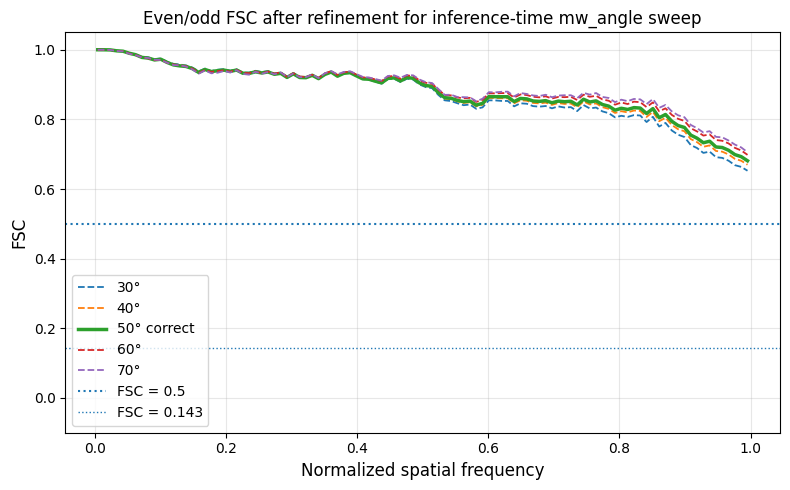

Saved to: C:\Users\chris\Desktop\Fabio\semester-project-deepdewedge\figures\FSC_even_odd_subexp01.png


In [10]:
plt.figure(figsize=(8, 5))

for angle in sorted(angles):
    if angle not in fsc_results:
        continue

    freqs = fsc_results[angle]["freqs"]
    fsc_values = fsc_results[angle]["fsc"]
    fsc_05_freq = fsc_results[angle]["fsc_05_freq"]

    if angle == 50:
        plt.plot(freqs, fsc_values, linewidth=2.5, label=f"{angle}° correct")
    else:
        plt.plot(freqs, fsc_values, linestyle="--", linewidth=1.3, label=f"{angle}°")

    # Mark FSC=0.5 crossing if it exists
    if fsc_05_freq is not None and np.isfinite(fsc_05_freq):
        plt.scatter(fsc_05_freq, 0.5, s=30)

plt.axhline(0.5, linestyle=":", linewidth=1.5, label="FSC = 0.5")
plt.axhline(0.143, linestyle=":", linewidth=1.0, label="FSC = 0.143")

plt.xlabel("Normalized spatial frequency", fontsize = 12)
plt.ylabel("FSC", fontsize = 12)
plt.title("Even/odd FSC after refinement for inference-time mw_angle sweep", fontsize = 12)
plt.ylim(-0.1, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs("../../figures", exist_ok=True)
save_path = "../../figures/FSC_even_odd_subexp01.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", os.path.abspath(save_path))

### Interpretation of the even/odd FSC angle sweep

The global even/odd FSC compares the consistency between the independently refined even and odd tomograms. In this sweep, the 30° condition shows the lowest correlation at high spatial frequencies, which is consistent with under-filling: the assumed missing wedge is too small, so parts of the true missing wedge remain uncorrected.

The 50° condition corresponds to the nominal/correct missing wedge angle and performs well. Interestingly, the 60° and 70° curves are slightly higher in the high-frequency range. This should not automatically be interpreted as physically better reconstruction. A larger assumed missing wedge may lead to stronger model-based correction or smoothing, which can increase even/odd consistency while potentially introducing shared bias or over-filling artifacts.

Therefore, the global FSC result should be interpreted together with qualitative XZ/YZ slices and Fourier-space power spectra.

### FSC only in the missing wedge

In [ ]:
def make_missing_wedge_mask(shape, mw_angle_deg, tilt_axis="y"):
    """
    Create a boolean Fourier-space mask for the missing wedge region.

    Assumes volume axes are (z, y, x), and the usual cryo-ET tilt axis is y.
    For tilt_axis="y", the missing wedge is visible in the central XZ Fourier slice.

    Returns
    -------
    missing_mask : np.ndarray of bool
        True where Fourier voxels are considered inside the missing wedge.
    """
    z, y, x = np.indices(shape)
    center = np.array(shape) // 2

    kz = z - center[0]
    ky = y - center[1]
    kx = x - center[2]

    eps = 1e-8

    if tilt_axis == "y":
        # In the XZ plane, compare vertical Fourier component kz
        # against horizontal component kx.
        angle_from_kx = np.degrees(np.arctan2(np.abs(kz), np.abs(kx) + eps))
        missing_mask = angle_from_kx > mw_angle_deg

    elif tilt_axis == "x":
        angle_from_ky = np.degrees(np.arctan2(np.abs(kz), np.abs(ky) + eps))
        missing_mask = angle_from_ky > mw_angle_deg

    else:
        raise ValueError("Only tilt_axis='y' or tilt_axis='x' implemented.")

    # Remove the exact Fourier origin from the missing wedge
    missing_mask[tuple(center)] = False

    return missing_mask



def compute_fsc_masked(vol1, vol2, fourier_mask=None, num_shells=None, subtract_mean=True):
    """
    Compute FSC between two volumes, optionally only over a Fourier-space mask.

    fourier_mask must have the same shape as the volumes and should be True
    for Fourier voxels included in the FSC calculation.
    """
    assert vol1.shape == vol2.shape, "Volumes must have the same shape."

    v1 = vol1.astype(np.float32).copy()
    v2 = vol2.astype(np.float32).copy()

    if subtract_mean:
        v1 = v1 - np.mean(v1)
        v2 = v2 - np.mean(v2)

    F1 = np.fft.fftshift(np.fft.fftn(v1))
    F2 = np.fft.fftshift(np.fft.fftn(v2))

    shape = vol1.shape

    if num_shells is None:
        num_shells = min(shape) // 2

    z, y, x = np.indices(shape)
    center = np.array(shape) // 2

    r = np.sqrt(
        (z - center[0])**2 +
        (y - center[1])**2 +
        (x - center[2])**2
    )

    r_max = min(shape) // 2
    shell_edges = np.linspace(0, r_max, num_shells + 1)

    if fourier_mask is None:
        fourier_mask = np.ones(shape, dtype=bool)

    shell_frequencies = []
    fsc_values = []
    n_voxels_per_shell = []

    for i in range(num_shells):
        shell_mask = (r >= shell_edges[i]) & (r < shell_edges[i + 1])
        mask = shell_mask & fourier_mask

        n_voxels = np.sum(mask)
        n_voxels_per_shell.append(n_voxels)

        if n_voxels == 0:
            shell_frequencies.append(np.nan)
            fsc_values.append(np.nan)
            continue

        F1_shell = F1[mask]
        F2_shell = F2[mask]

        numerator = np.sum(F1_shell * np.conj(F2_shell))
        denominator = np.sqrt(
            np.sum(np.abs(F1_shell)**2) *
            np.sum(np.abs(F2_shell)**2)
        )

        if denominator == 0:
            fsc = np.nan
        else:
            fsc = np.real(numerator / denominator)

        shell_center = 0.5 * (shell_edges[i] + shell_edges[i + 1])
        normalized_frequency = shell_center / r_max

        shell_frequencies.append(normalized_frequency)
        fsc_values.append(fsc)

    return (
        np.array(shell_frequencies),
        np.array(fsc_values),
        np.array(n_voxels_per_shell),
    )

In [ ]:
missing_mask_50 = make_missing_wedge_mask(
    even_refined_by_angle[50].shape,
    mw_angle_deg=50,
    tilt_axis="y"
)

In [ ]:
freqs_evenodd_full, fsc_evenodd_full, _ = compute_fsc_masked(
    even_refined_by_angle[50],
    odd_refined_by_angle[50],
    fourier_mask=None,
    subtract_mean=False
)

freqs_evenodd_mw, fsc_evenodd_mw, _ = compute_fsc_masked(
    even_refined_by_angle[50],
    odd_refined_by_angle[50],
    fourier_mask=missing_mask_50,
    subtract_mean=False
)


plt.figure(figsize=(8, 5))

plt.plot(
    freqs_evenodd_full,
    fsc_evenodd_full,
    label="even refined vs odd refined, whole volume"
)

plt.plot(
    freqs_evenodd_mw,
    fsc_evenodd_mw,
    label="even refined vs odd refined, 50° missing wedge only"
)

plt.axhline(0.5, linestyle=":", linewidth=1.5, label="FSC = 0.5")
plt.axhline(0.143, linestyle=":", linewidth=1.0, label="FSC = 0.143")

plt.xlabel("Normalized spatial frequency")
plt.ylabel("FSC")
plt.title("Gold-standard-like FSC inside the missing wedge")
plt.ylim(-0.1, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()